In [1]:
import numpy as np
import timeit
import pandas as pd
from typing import NamedTuple, List, Tuple
from IPython.display import display
from shapely.geometry import Point, Polygon
from shapely.geometry.polygon import Polygon as ShapelyPolygon
import pickle
import sys
# Add measurement mcts python package to path
sys.path.append('../src/measurement_mcts')
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment
from measurement_mcts.utils.utils import get_ellipse_scaling
from measurement_mcts.environment.object_manager import ObjectManager, ObjectTuple

/home/austin/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [14]:
env = MeasurementControlEnvironment(init_reset=False)
car_state = env.car.reset()
env.object_manager.reset(car_state)

Toy Measurement Control Initialized


In [3]:
# Load the objects
with open('../state_configurations/new_format_test1.pkl', 'rb') as f:
    objects = pickle.load(f)

car_state = objects[0]
env.object_manager.obstacle_means = objects[1]
env.object_manager.obstacle_radii = objects[2]
env.object_manager.occlusion_means = objects[3]
env.object_manager.occlusion_radii = objects[4]
env.object_manager.oois = objects[5]

Elapsed time: 0.0016326120003213873
Observation: {0: [0, 1]}


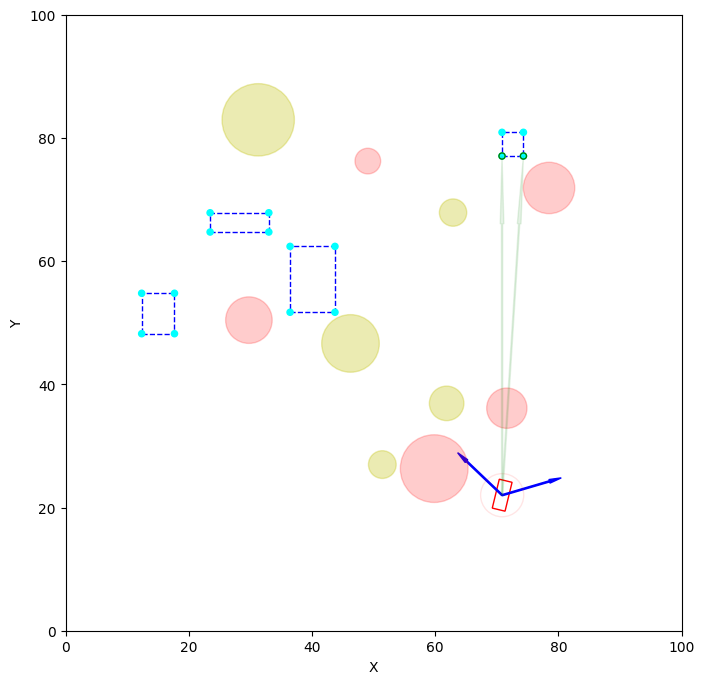

In [15]:
# car_state[0:2] = [19, 20]
# car_state[3] = np.radians(135)
env.car.draw_car_state(car_state)
start_time = timeit.default_timer()
in_collision_obs, in_collision_ocl, in_collision_oois = env.object_manager.check_collision(car_state)
observation = env.object_manager.get_observation(car_state)
print(f'Elapsed time: {timeit.default_timer() - start_time}')
print(f'Observation: {observation}')
env.object_manager.draw_objects(car_state, in_collision_obs, in_collision_ocl, in_collision_oois, observation=observation)
env.ui.plot()

In [29]:
save_objects = (car_state,
                env.object_manager.obstacle_means,
                env.object_manager.obstacle_radii,
                env.object_manager.occlusion_means,
                env.object_manager.occlusion_radii,
                env.object_manager.oois)
# pickle the objects
with open('../state_configurations/new_format_test1.pkl', 'wb') as f:
    pickle.dump(save_objects, f)